# Assignment 3: Analysis of Local Track Discontinuities in Railway

## Laboration Participant
Viktor Lindberg || viklio-3@student.ltu.se 

## 1. Problem Description


Switches are an essential, safety-critical part of railway infrastructure. Compared to open tracks, their
complex geometry results in increased dynamic loading on the track superstructure caused by passing
trains, leading to higher maintenance costs. To improve efficiency, condition monitoring methods
specific to railway switches are necessary. A common approach to monitoring the track superstructure
is to measure the acceleration caused by vehicle-track interaction. Local interruptions in the wheel-
rail contact, caused by factors such as defects or track discontinuities, appear in the data as transient
impact events.

In this assignment, preprocessed data has been used to train two different machine learning/predictive model. The model is trained on common features between three different datasets (X) to predict whether an event will be either normal or abnormal (Y). The machine learning model is trained using an 80-20 split with two different methods. 

The first method: A standard 80-20 split, where the model tries to learn/find patterns whether an event is normal (0) or abnormal (1). The remaining 20 % of the data is used as a test set to see how well the model have learned and can adapt to data. 

The second method: The training data is split into 5 subsets. For each fold, 4 subsets are used to train the model and the remaining subset is used for validation. This process is repeated five times, so each subset is used once as validation. The results are averaged to provide a more stable estimate of model performance. 

After cross-validation we can use the results from the 5-fold-validation to tune/find optimal hyperparamters for our predictive model. 

## 2. General results and conclusions


The first method (80-20 train split without tuning) we can see that when testing the trained model on the testing data (the 20 % not used for training) we can see in the classification report precision = 1.00 for normal events. This means that every time a normal event was predicted it was correct. The precision for abnormal events = 0.90. This means that 10 % of our predicted abnormal events were actually normal. The overall accruacy for the model was 93 % and the results suggest that the model tend to predict more reliably to normal events compared to abnormal events.

The second method split the training data into 5 subsets. This method is often used to evaluate a model and tune a model based on different "hyperparameters". The cross-validation (cv) results show a mean CV score of 96.666 %, which represents the average performance across the 5 validation runs. This means that the when the model is tested on data not used for training, and it correctly predicts about 96.666 % of the predictions correctly (True prediction = true labeel). What this suggests is that our training data is quite consistent and reliable no matter what sets we choose to train on. 

Based on the results of the 5-fold validation, tuning of hyperparameters can be done to make the trained model generalize and predict more accurate. (Default for SVM_model, C = 1.0, Gamma = 1/NumberOfFeatures = 1/16 = 0,0625). The best hypermeters found based on 25 combinations (5*5):
- **Best hyperparameters from 5-fold CV: {'svc__C': 1, 'svc__gamma': 0.0625}**

This means the original 80-20 model is the best model based on the hyperparameters that was tested to optimize the model. This makes sense because the datasets consist of only 150 datasets, limiting the benefits of tuning. With more data and if the default model performed worse, hyperparameter tuning could potentially find parameters that improves the perdictability and generalization of the model.

## 3. Method and code

### 3.1 Import of used libraries

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline


### 3.2 Reading and Merging the Data

In [26]:
# read the data file into dataframes and merge into one single dataframe for easier analysis
os.chdir("C:\\Users\\vikto\\Desktop\\Skola'\\Andra Kurser\\D7015B - Industrial AI and eMaintenence\\Assignment 3")
trail1 = pd.read_csv("trail1_data.csv")
trail2 = pd.read_csv("trail2_data.csv")
trail3 = pd.read_csv("trail3_data.csv")


In [27]:
#Merge the three trails into one DataFrame for easier analysis
merged_data = pd.concat([trail1, trail2, trail3], ignore_index=True)
print(merged_data.shape)
merged_data.drop(columns = ['start_time', 'axle', 'cluster', 'tsne_1', 'tsne_2'], inplace = True) #Drop the columns that are not needed for the analysis
merged_data["event"] = (merged_data["event"].str.lower() != "normal").astype(int) #Convert the event column to binary, where 0 = normal event and 1 is for any other event
print(merged_data.shape)

print(merged_data) #Verify data and check structure


(150, 22)
(150, 17)
             mean       std       max       min     range  skewness  \
0   -4.765466e-06  0.001350  0.007542 -0.006189  0.013731 -0.004788   
1   -5.524224e-06  0.024360  0.215148 -0.249093  0.464241 -0.036717   
2    1.592743e-05  0.003036  0.013389 -0.014713  0.028103 -0.058478   
3    6.701540e-05  0.024002  0.298642 -0.290638  0.589279  0.990779   
4   -1.478153e-04  0.008061  0.024657 -0.042391  0.067048 -0.331677   
..            ...       ...       ...       ...       ...       ...   
145  4.331390e-05  0.004245  0.011402 -0.018020  0.029422 -0.444835   
146 -1.099413e-05  0.005241  0.040248 -0.028953  0.069201  0.107682   
147  3.509744e-07  0.003042  0.010449 -0.012557  0.023006 -0.204318   
148 -1.468078e-05  0.002244  0.009144 -0.009182  0.018326  0.020199   
149  4.913164e-06  0.001840  0.008671 -0.009114  0.017785  0.058101   

      kurtosis       rms  crest_factor  variance  zero_crossings  \
0     0.472182  0.001350      5.587349  0.000002           

### 3.3 Method 1: Creating and analyzing 80-20 trained model


When normalizing the data, we want to exclude the event column since it is is a binary variable and we should only normalize features (X).
We will normalize only on the trained data (X_train) and then apply it to test_data (X_test) to not let the model have access to test data during training. This is important to prevent data leakage and ensure that the model generalizes well to unseen data. We want to normalize our data before analyzing it. This is to balance scaling between different feautures that might have different ranges and units.

#### 3.3.1 80-20 split to train and test data

In [28]:

X = merged_data.drop(columns=['event']) 
y = merged_data['event']


In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, #y is the target variable (event) for training and testing.
                                                    test_size=0.2, #20 % of data for test and 80 % for training
                                                    random_state=42, 
                                                    stratify=y) #Same proportion of normal/abnormal events in both training and test sets


#### 3.3.2 Normalizing the data and training the svm_model

In [30]:

scaler = StandardScaler() #Standardscaler comes from sklearn.preproccing package and standardizes to N(0,1) distiribution
X_train_scaled = scaler.fit_transform(X_train) #Fit the scaler on the training data and transform it
X_test_scaled = scaler.transform(X_test) #Transform the test data using the same scaler fitted on the training data

svm_model = SVC(kernel='rbf', probability=True, random_state=42) #Create an SVM model with RBF kernel, random_state=42 basically means we can re-use the same seed
svm_model.fit(X_train_scaled, y_train) #Fit the SVM model on the scaled training data (80/20 split)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


#### 3.3.3 Testing the trained model on the test set

When testing the trained model we can visualize the results from the classification_report using a confusion_matrix. The results are explained in the first section of this report under general results and conclusion

              precision    recall  f1-score   support

           0       1.00      0.83      0.91        12
           1       0.90      1.00      0.95        18

    accuracy                           0.93        30
   macro avg       0.95      0.92      0.93        30
weighted avg       0.94      0.93      0.93        30



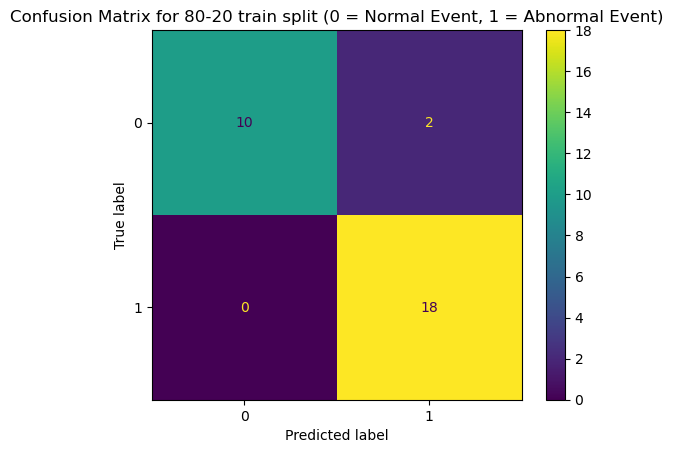

In [31]:

#Evaluate the model on the test set
y_pred = svm_model.predict(X_test_scaled) #Predict the labels for the test set using the trained SVM model

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_) 
disp.plot() #Plot the confusion matrix
plt.title("Confusion Matrix for 80-20 train split (0 = Normal Event, 1 = Abnormal Event)")
plt.show()

### 3.4 Method 2: 5-fold cross-validation split

5-fold cross-validation splits training data into 5 subsets, trains on 4 of these and test on remaining subsets, and repeats for each subset. This model is then used on test set to evaluate performance. 

#### 3.4.1 5-fold Cross-validation and Tuning of Hyperparameters

To do this make_pipeline is used from the skl.learn package. make_pipeline combines preprocessing + modeling into a single object which simplifies evalaution and hyperparameter tuning. This means when we perform our cross validation "cross_val_score" we can feed raw data that is normalized by the pipeline (see the first two lines of code.)

Then a grid_search is done to find whether there is any more suitable paramters for the predictive model (see parameter valeus in code)

The  mean CV_score of showed to be 96.666 %, which represents the average performance across the 5 validation runs. This means that the when the model is tested on data not used for training, and it correctly predicts about 96.666 % of the predictions correctly (True prediction = true labeel). What this suggests is that our training data is quite consistent and reliable no matter what sets we choose to train on.  

In [32]:

pipeline = make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True, random_state=42)) #Create a pipeline that includes standard scaling and new SVM model to train on. 
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5)
print("CV scores:", cv_scores)
print("Mean CV score:", np.mean(cv_scores))

#Hyperparameter grid for RBF SVM
param_grid = { #Parameters to search over for tuning the SVM model. Total 5x5 = 25 combinations to evaluate over cv = 5 folds --> 25*5 = 125 total model fits to evaluate and compare.
    'svc__C': [0.1, 0.05, 1, 10, 50], #C regulates trade-off between training error and testing error. High C prioritize minimizing training errors (sensitive to outliers). Low C allows more training errors but can improve generalization.
    'svc__gamma': [0.01, 0.0625, 0.1, 0.5, 1] #Gamma describes how local training points influence other data points. High gamma means data points only affect nearby points, lower gamma means data points have further reach and thus higher weight on more distant points.
}

grid = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1) #Creates the searchgrid
grid.fit(X_train, y_train) #Fit grid to training data, this will evaluate all combinations of hyperparameters in param_grid using 5-fold cross-validation and find the best combination based on mean CV score.
grid.cv_results_
print("Best CV score:", grid.best_score_) #Best mean CV score across all hyperparameter combinations
#Best hyperparameters from CV
print("Best hyperparameters from 5-fold CV:", grid.best_params_)



CV scores: [0.95833333 1.         0.95833333 0.91666667 1.        ]
Mean CV score: 0.9666666666666668
Best CV score: 0.9666666666666668
Best hyperparameters from 5-fold CV: {'svc__C': 1, 'svc__gamma': 0.0625}


#### 3.4.2 Evaluation and training of new CV_model

Based on the best hyperparameters we can optimize our new CV_model. In this case the optimal hyperparameters from 5-fold CV was found to be C = 1 and gamma = 0.0625, which are the same that are used for the original SVC_model. For original model standard values are:
- **C = 1**
- **Gamma = 1/NumberOfFeatures = 1/16 = 0.0625**

This is why both trained models perform the same. If more data would be available to train and test the model, hyperparameterization would be more beneficial and likely to improve the performance of the predictive model - especially if the original model has low accuracy.

CV-Tuned SVM Performance on Test Set:
              precision    recall  f1-score   support

           0       1.00      0.83      0.91        12
           1       0.90      1.00      0.95        18

    accuracy                           0.93        30
   macro avg       0.95      0.92      0.93        30
weighted avg       0.94      0.93      0.93        30



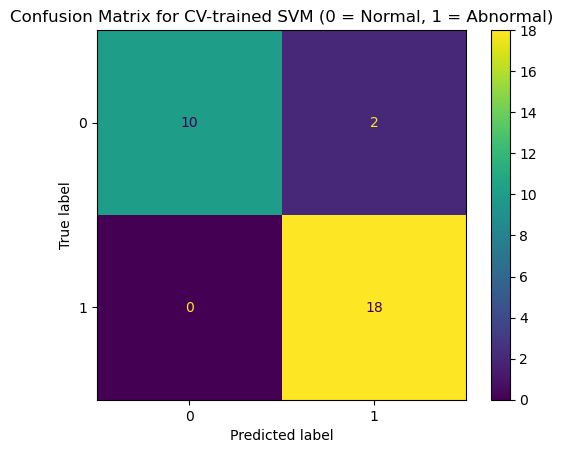

In [33]:

#Evaluate final CV-tuned model on test set
best_model = grid.best_estimator_
y_test_pred_cv = best_model.predict(X_test)

print("CV-Tuned SVM Performance on Test Set:")
print(classification_report(y_test, y_test_pred_cv)) 

cm_cv = confusion_matrix(y_test, y_test_pred_cv) #Compute the confusion matrix for trained cv model on test set
disp_cv = ConfusionMatrixDisplay(confusion_matrix=cm_cv, display_labels=best_model.named_steps['svc'].classes_)
disp_cv.plot()
plt.title("Confusion Matrix for CV-trained SVM (0 = Normal, 1 = Abnormal)")
plt.show()
